# f6_m01c_shap_cohortes.ipynb
**TFM: Pronóstico del Éxito y del Abandono en los Títulos de Grado de la UJI**

| | |
|---|---|
| **Autora** | María José Morte Ruiz |
| **Institución** | UOC + Universitat Jaume I |
| **Email** | mjmorteruiz@uoc.edu · morte@uji.es |
| **Fase** | 6 — Interpretabilidad y Evaluación Final |
| **Módulo** | M01c — SHAP Cohortes |

---

## 🎯 Qué hace

Analiza la importancia SHAP segmentada por cohortes: rama de conocimiento y titulación.
Responde a: ¿qué variables son más importantes para predecir abandono en cada grupo?
¿Es el modelo igual de explicable en todas las titulaciones?
Modelo usado: CatBoost__balanced.

## 📋 Requisitos

- `results/fase6/shap_global_catboost.pkl` — generado por f6_m01a
- `results/fase6/shap_global_catboost_meta.json` — metadatos validación
- `data/05_modelado/X_test_prep.parquet`
- `data/05_modelado/X_test.parquet` — índices originales para join
- `data/05_modelado/y_test.parquet`
- `data/05_modelado/models/CatBoost__balanced.pkl`
- `data/03_features/df_exp_target_eda.parquet` — fuente de titulacion y rama

## 📤 Genera

| Archivo | Contenido |
|---|---|
| `results/fase6/shap_cohortes_rama.parquet` | Importancias SHAP por rama |
| `results/fase6/shap_cohortes_titulacion.parquet` | Importancias SHAP por titulación |
| `results/fase6/shap_cohortes_rama_top10.png` | Heatmap por rama |
| `results/fase6/shap_cohortes_titulacion_top8.png` | Heatmap por titulación |
| `docs/html/fase6/m01c_shap_cohortes.html` | Informe HTML |

## 🔄 Flujo

```
shap_global_catboost.pkl (m01a) + X_test_prep + X_test + df_exp_target_eda
    ↓ Validar cache SHAP
    ↓ Recuperación de contexto: join X_test.index → df_exp_target_eda
      (titulacion, rama no están en X_test_prep — se perdieron en preprocesado Fase 5)
    ↓ Segmentar por rama → importancias SHAP por rama
    ↓ Segmentar por titulación (>=30 obs) → importancias SHAP por titulación
    ↓ Heatmaps
    → parquets + docs/html/fase6/m01c_shap_cohortes.html
```

## ➡️ Siguiente

`f6_m01d_shapash.ipynb` — dashboard interactivo de interpretabilidad


In [1]:
# ============================================================
# CELDA 1: CONFIGURACIÓN DE RUTAS
# ============================================================
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def _encontrar_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / 'src').is_dir():
            return parent
    raise FileNotFoundError('No se encontró src/ subiendo desde ' + str(start))

ROOT = _encontrar_root(Path.cwd())
sys.path.insert(0, str(ROOT))

DIR_DATA     = ROOT / 'data' / '05_modelado'
DIR_FEATURES = ROOT / 'data' / '03_features'
DIR_MODELS   = ROOT / 'data' / '05_modelado' / 'models'
DIR_RESULTS  = ROOT / 'results' / 'fase6'
DIR_HTML     = ROOT / 'docs' / 'html' / 'fase6'
DIR_RESULTS.mkdir(parents=True, exist_ok=True)
DIR_HTML.mkdir(parents=True, exist_ok=True)

print(f'ROOT:        {ROOT}')
print(f'DIR_RESULTS: {DIR_RESULTS}')

ROOT:        C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI
DIR_RESULTS: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\results\fase6


In [2]:
# ============================================================
# CELDA 2: IMPORTS
# ============================================================
import json
import hashlib
import base64
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
import shap
from src.html.render import render_pagina_desde_fichero

matplotlib.rcParams['figure.dpi'] = 120

print('Imports OK.')
from src.config_entorno import RAMAS_NOMBRES, COLORES_RAMAS_ABR, NOMBRES_LEGIBLES_FEATURES, FEATURES_NUM_MODELO
def nombre_legible(f): return NOMBRES_LEGIBLES_FEATURES.get(f, f.replace("_", " "))


Imports OK.


In [3]:
# ============================================================
# CELDA 3: CARGAR DATOS Y MODELO
# X_test (sin prep): índices originales para join con df_ref.
# X_test_prep: features numéricas preprocesadas para SHAP.
# Nota: titulacion y rama NO están en X_test_prep — se perdieron
# en el preprocesado de Fase 5. Se recuperan mediante join
# (proceso llamado 'recuperación de contexto').
# ============================================================
X_test       = pd.read_parquet(DIR_DATA / 'X_test.parquet')
X_test_prep  = pd.read_parquet(DIR_DATA / 'X_test_prep.parquet')
y_test       = pd.read_parquet(DIR_DATA / 'y_test.parquet').squeeze()
pipeline_cat = joblib.load(DIR_MODELS / 'CatBoost__balanced.pkl')

feature_names = X_test_prep.columns.tolist()

print(f'X_test:      {X_test.shape}')
print(f'X_test_prep: {X_test_prep.shape}  ← features numéricas para SHAP')
print(f'y_test:      {y_test.shape}')
print(f'Features:    {len(feature_names)}')

X_test:      (6725, 27)
X_test_prep: (6725, 27)  ← features numéricas para SHAP
y_test:      (6725,)
Features:    27


In [4]:
# ============================================================
# CELDA 4: CARGAR SHAP GLOBAL CON VALIDACIÓN
# Reutilizamos shap_cat de m01a — no recalculamos.
# ============================================================
def _hash_df(df: pd.DataFrame, n: int = 500) -> str:
    muestra = df.iloc[:n].values.tobytes()
    return hashlib.md5(muestra).hexdigest()[:12]

RUTA_SHAP_CAT = DIR_RESULTS / 'shap_global_catboost.pkl'
RUTA_META_CAT = DIR_RESULTS / 'shap_global_catboost_meta.json'

if not RUTA_SHAP_CAT.exists():
    raise FileNotFoundError(
        'No se encontró shap_global_catboost.pkl.\n'
        'Ejecuta primero f6_m01a_shap_global.ipynb.'
    )

if RUTA_META_CAT.exists():
    meta = json.loads(RUTA_META_CAT.read_text())
    meta_esp = {
        'n_obs':      int(len(X_test_prep)),
        'n_features': int(X_test_prep.shape[1]),
        'hash_xtest': _hash_df(X_test_prep),
    }
    if meta != meta_esp:
        raise ValueError(
            f'Cache SHAP desactualizado.\nGuardado: {meta}\nEsperado: {meta_esp}\n'
            'Ejecuta f6_m01a_shap_global.ipynb para regenerar.'
        )

shap_cat = joblib.load(RUTA_SHAP_CAT)

assert shap_cat.values.shape == (len(X_test_prep), len(feature_names)), (
    f'Shape SHAP {shap_cat.values.shape} no coincide con '
    f'X_test_prep ({len(X_test_prep)}, {len(feature_names)})'
)
print(f'✅ shap_cat cargado y validado: {shap_cat.values.shape}')

✅ shap_cat cargado y validado: (6725, 27)


In [5]:
# ============================================================
# CELDA 5: RECUPERACIÓN DE CONTEXTO — JOIN TITULACIÓN Y RAMA
# titulacion y rama no están en X_test_prep (preprocesado Fase 5
# las eliminó). Se recuperan desde df_exp_target_eda usando los
# índices de X_test como posiciones iloc en df_ref.
# Validado: max(X_test.index) < len(df_ref) → sin gaps.
# ============================================================
prob  = pipeline_cat.predict_proba(X_test_prep)[:, 1]
y_arr = y_test.values.ravel()
print(f'Probabilidades: min={prob.min():.3f} max={prob.max():.3f} media={prob.mean():.3f}')

df_ref  = pd.read_parquet(DIR_FEATURES / 'df_exp_target_eda.parquet')
df_meta = df_ref[['per_id_ficticio', 'titulacion', 'rama', 'situacion_laboral']].iloc[X_test.index].copy()
df_meta.index = X_test.index
df_meta['trabaja']  = df_meta['situacion_laboral'].apply(
    lambda x: 'Trabaja' if str(x).lower() not in ['inactivo o desempleado','nan'] else 'No trabaja')
df_meta['y_real']   = y_arr
df_meta['prob_cat'] = prob

print(f'df_ref shape:        {df_ref.shape}')
print(f'df_meta shape:       {df_meta.shape}')
print(f'Titulaciones únicas: {df_meta["titulacion"].nunique()}')
print(f'Ramas únicas:        {df_meta["rama"].nunique()}')
print(f'Ramas: {sorted(df_meta["rama"].dropna().unique())}')

# Verificar que el join es correcto
assert len(df_meta) == len(X_test_prep), 'ERROR: df_meta y X_test_prep tienen distinto nº de filas'
assert df_meta['titulacion'].notna().mean() > 0.95, 'ERROR: más del 5% de titulaciones nulas'

Probabilidades: min=0.002 max=0.998 media=0.367
df_ref shape:        (33621, 49)
df_meta shape:       (6725, 5)
Titulaciones únicas: 40
Ramas únicas:        5
Ramas: ['EX', 'HU', 'SA', 'SO', 'TE']


In [6]:
# ============================================================
# CELDA 6: EXTRAER MATRIZ DE SHAP VALUES
# Convertir objeto Explanation a array numpy (n_obs × n_features).
# Para clasificación binaria con shape (n, p, 2) tomamos clase 1.
# ============================================================
shap_vals = shap_cat.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]

df_shap = pd.DataFrame(shap_vals, columns=feature_names, index=X_test.index)

print(f'df_shap shape: {df_shap.shape}')  # esperado: (6725, 27)

df_shap shape: (6725, 27)


In [7]:
# Mapeo abreviaturas → nombres completos de rama
# RAMAS_NOMBRES importado desde src/config_entorno.py

# ============================================================
# CELDA 7: IMPORTANCIAS SHAP POR RAMA
# Para cada rama: media de |SHAP| por feature → ranking.
# Permite ver si las mismas variables predicen abandono en
# todas las ramas o si hay dinámicas diferenciadas.
# ============================================================
ramas = sorted(df_meta['rama'].dropna().unique())
imp_por_rama = {}

for rama in ramas:
    mask = df_meta['rama'] == rama
    n    = mask.sum()
    imp  = df_shap.loc[mask].abs().mean()
    imp_por_rama[rama] = imp
    tasa = df_meta.loc[mask, 'y_real'].mean()
    print(f'{rama:35s} | n={n:4d} | tasa_abandono={tasa:.2%}')

df_imp_rama = pd.DataFrame(imp_por_rama).T
df_imp_rama.to_parquet(DIR_RESULTS / 'shap_cohortes_rama.parquet')
print('\n✅ shap_cohortes_rama.parquet guardado.')

EX                                  | n= 177 | tasa_abandono=35.59%
HU                                  | n= 569 | tasa_abandono=25.66%
SA                                  | n= 686 | tasa_abandono=15.31%
SO                                  | n=3761 | tasa_abandono=28.50%
TE                                  | n=1532 | tasa_abandono=37.92%

✅ shap_cohortes_rama.parquet guardado.


In [ ]:
# ============================================================
# CELDA 7b: SEGMENTACIÓN SHAP POR SITUACIÓN LABORAL 🏆
# Trabajadores vs no trabajadores — ¿usa el modelo features
# distintas para cada grupo?
# n_anios_trabajando es top 1 en SHAP global, pero ¿cómo
# afectan las otras features a cada grupo por separado?
# ============================================================
grupos_laboral = df_meta['trabaja'].unique()

imp_por_laboral = {}
for grupo in sorted(grupos_laboral):
    idx_grupo = df_meta[df_meta['trabaja'] == grupo].index
    if len(idx_grupo) < 30:
        continue
    shap_grupo = df_shap.loc[idx_grupo]
    imp_por_laboral[grupo] = shap_grupo.abs().mean().sort_values(ascending=False)
    print(f'{grupo} (n={len(idx_grupo)}): top 3 = {imp_por_laboral[grupo].head(3).index.tolist()}')

if len(imp_por_laboral) >= 2:
    # Heatmap comparativo: top 10 features por consenso entre grupos
    top_feats_lab = pd.DataFrame(imp_por_laboral).fillna(0)
    top_feats_lab['media'] = top_feats_lab.mean(axis=1)
    top10_lab = top_feats_lab.nlargest(10, 'media').drop(columns='media')

    fig, ax = plt.subplots(figsize=(max(6, len(imp_por_laboral)*2.5), 6))
    im = ax.imshow(top10_lab.values.T, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(top10_lab.index)))
    ax.set_xticklabels([nombre_legible(f) for f in top10_lab.index],
                       rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(top10_lab.columns)))
    ax.set_yticklabels(top10_lab.columns, fontsize=10)
    ax.set_title(
        'Fase 6 — SHAP por situación laboral\n'        '¿Qué features usa el modelo para cada grupo?',
        fontsize=12
    )
    plt.colorbar(im, ax=ax, label='Mean |SHAP|')
    plt.tight_layout()
    ruta_laboral = DIR_RESULTS / 'shap_cohortes_laboral.png'
    plt.savefig(ruta_laboral, dpi=120, bbox_inches='tight')
    plt.close()
    print(f'✅ Heatmap SHAP por situación laboral guardado.')

    # Diferencias clave entre grupos
    if 'Trabaja' in imp_por_laboral and 'No trabaja' in imp_por_laboral:
        diff_lab = (imp_por_laboral['Trabaja'] - imp_por_laboral['No trabaja']).abs().nlargest(5)
        print('\nTop 5 features con mayor diferencia SHAP Trabaja vs No trabaja:')
        for f, d in diff_lab.items():
            print(f'  {nombre_legible(f):35s}: Δ={d:.4f}')
else:
    ruta_laboral = None
    print('⚠️  Grupos insuficientes para comparativa.')


In [8]:
# ============================================================
# CELDA 8: IMPORTANCIAS SHAP POR TITULACIÓN
# Solo titulaciones con >= 30 obs en test — muestra mínima
# para que la media de SHAP sea estadísticamente robusta.
# ============================================================
MIN_OBS = 30
conteo_tit = df_meta['titulacion'].value_counts()
titulaciones_validas = conteo_tit[conteo_tit >= MIN_OBS].index.tolist()
print(f'Titulaciones con >= {MIN_OBS} obs en test: {len(titulaciones_validas)}')

imp_por_tit = {}
for tit in titulaciones_validas:
    mask = df_meta['titulacion'] == tit
    n    = mask.sum()
    imp  = df_shap.loc[mask].abs().mean()
    imp_por_tit[tit] = imp
    tasa = df_meta.loc[mask, 'y_real'].mean()
    print(f'{tit[:50]:50s} | n={n:4d} | abandono={tasa:.2%}')

df_imp_tit = pd.DataFrame(imp_por_tit).T
df_imp_tit.to_parquet(DIR_RESULTS / 'shap_cohortes_titulacion.parquet')
print('\n✅ shap_cohortes_titulacion.parquet guardado.')

Titulaciones con >= 30 obs en test: 36
Grado en Administración de Empresas                | n= 451 | abandono=48.12%
Grado en Maestro en Educación Primaria             | n= 446 | abandono=22.65%
Grado en Derecho                                   | n= 390 | abandono=37.69%
Grado en Psicología                                | n= 366 | abandono=20.77%
Grado en Finanzas y Contabilidad                   | n= 360 | abandono=52.22%
Grado en Maestro en Educación Infantil             | n= 306 | abandono=15.03%
Grado en Ingeniería en Diseño Industrial y Desarro | n= 265 | abandono=30.94%
Grado en Publicidad y Relaciones Públicas          | n= 256 | abandono=12.11%
Grado en Ingeniería Informática                    | n= 247 | abandono=41.70%
Grado en Comunicación Audiovisual                  | n= 234 | abandono=17.52%
Grado en Periodismo                                | n= 228 | abandono=14.47%
Grado en Traducción e Interpretación               | n= 222 | abandono=9.91%
Grado en Relaciones Labora

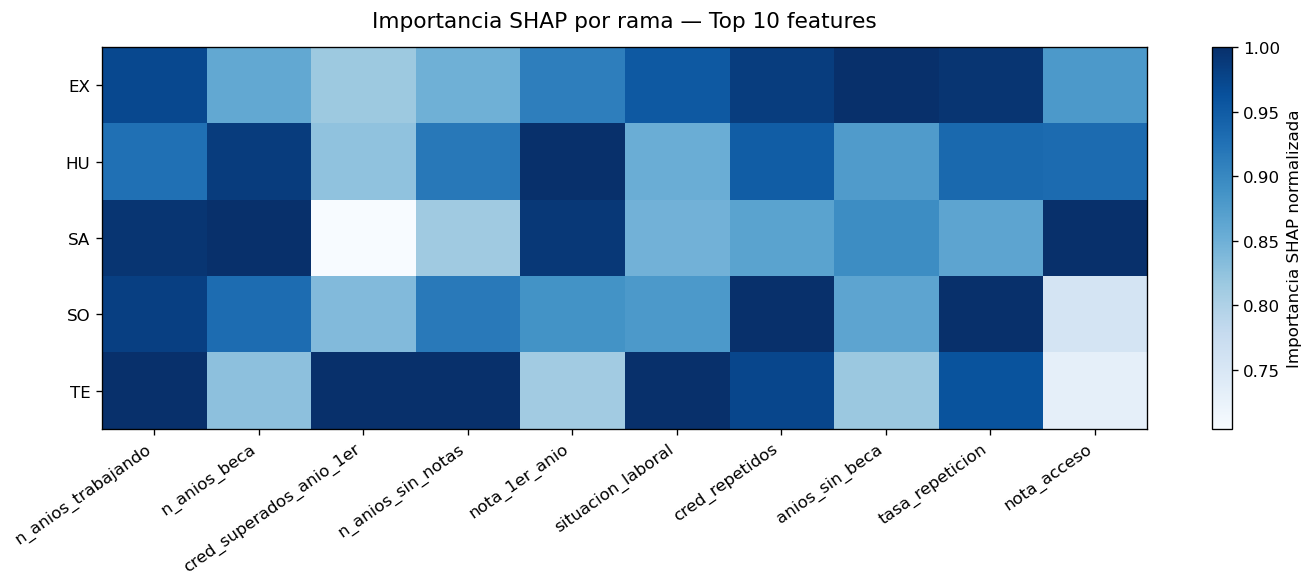

✅ Heatmap rama guardado.


In [9]:
# ============================================================
# CELDA 9: GRÁFICO 1 — HEATMAP SHAP POR RAMA
# Filas = ramas, columnas = top 10 features globales.
# Normalizado por columna: azul oscuro = muy importante en esa rama.
# ============================================================
top10_global = df_shap.abs().mean().nlargest(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
data_heatmap = df_imp_rama[top10_global]
data_norm    = data_heatmap.div(data_heatmap.max())

im = ax.imshow(data_norm.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(top10_global)))
ax.set_xticklabels(top10_global, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(data_norm)))
# Usar nombres completos de rama en el eje Y
labels_rama = [RAMAS_NOMBRES.get(r, r) for r in data_norm.index]
ax.set_yticklabels(labels_rama, fontsize=10)
plt.colorbar(im, ax=ax, label='Importancia SHAP normalizada')
ax.set_title('Importancia SHAP por rama — Top 10 features', fontsize=13, pad=12)
plt.tight_layout()
ruta_heatmap_rama = DIR_RESULTS / 'shap_cohortes_rama_top10.png'
plt.savefig(ruta_heatmap_rama, dpi=120, bbox_inches='tight')
plt.show()
print('✅ Heatmap rama guardado.')

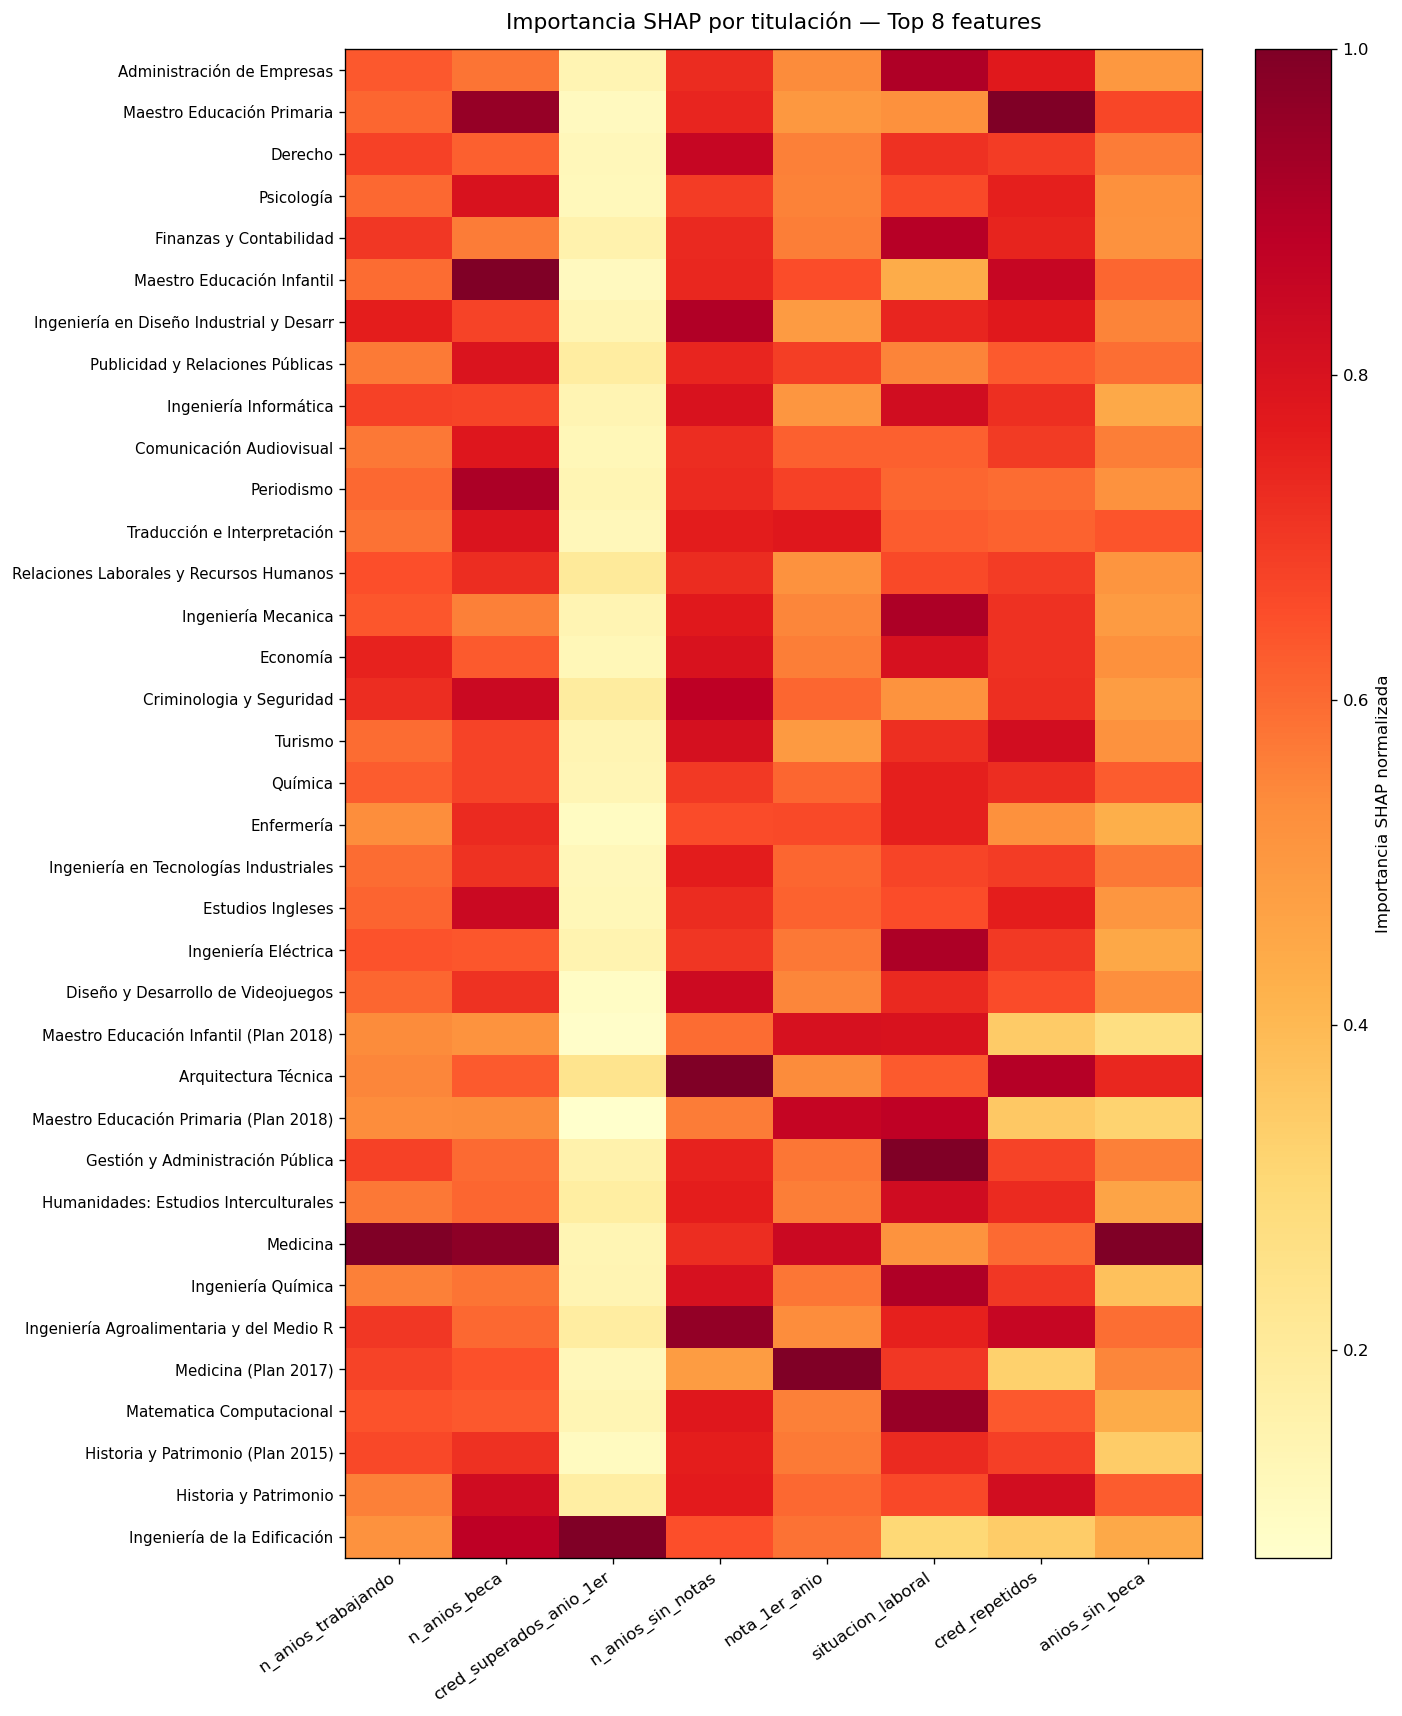

✅ Heatmap titulación guardado.


In [10]:
# ============================================================
# CELDA 10: GRÁFICO 2 — HEATMAP SHAP POR TITULACIÓN
# Filas = titulaciones (>=30 obs), columnas = top 8 features.
# Abreviamos nombres para que quepan en el eje Y.
# ============================================================
top8_global = df_shap.abs().mean().nlargest(8).index.tolist()

nombres_cortos = [
    t.replace('Grado en Maestro en ', 'Maestro ').replace('Grado en ', '')[:40]
    for t in df_imp_tit.index
]

fig, ax = plt.subplots(figsize=(12, max(6, len(df_imp_tit) * 0.4)))
data_heatmap_tit = df_imp_tit[top8_global]
data_norm_tit    = data_heatmap_tit.div(data_heatmap_tit.max())

im2 = ax.imshow(data_norm_tit.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(top8_global)))
ax.set_xticklabels(top8_global, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(nombres_cortos)))
ax.set_yticklabels(nombres_cortos, fontsize=9)
plt.colorbar(im2, ax=ax, label='Importancia SHAP normalizada')
ax.set_title('Importancia SHAP por titulación — Top 8 features', fontsize=13, pad=12)
plt.tight_layout()
ruta_heatmap_tit = DIR_RESULTS / 'shap_cohortes_titulacion_top8.png'
plt.savefig(ruta_heatmap_tit, dpi=120, bbox_inches='tight')
plt.show()
print('✅ Heatmap titulación guardado.')

In [11]:
# ============================================================
# CELDA 11: ANÁLISIS — FEATURE DOMINANTE POR RAMA Y TITULACIÓN
# Qué variable lidera en cada cohorte — útil para defensa.
# ============================================================
print('Feature más importante por RAMA:')
for rama in df_imp_rama.index:
    top_feat = df_imp_rama.loc[rama].idxmax()
    top_val  = df_imp_rama.loc[rama].max()
    tasa     = df_meta[df_meta['rama'] == rama]['y_real'].mean()
    print(f'  {rama:35s} → {top_feat:30s} ({top_val:.4f}) | abandono={tasa:.2%}')

print('\nFeature más importante por TITULACIÓN (top 10 tasa abandono):')
tasas_tit = (
    df_meta[df_meta['titulacion'].isin(titulaciones_validas)]
    .groupby('titulacion')['y_real'].mean()
    .nlargest(10)
)
for tit in tasas_tit.index:
    if tit in df_imp_tit.index:
        top_feat = df_imp_tit.loc[tit].idxmax()
        top_val  = df_imp_tit.loc[tit].max()
        tasa     = tasas_tit[tit]
        print(f'  {tit[:45]:45s} → {top_feat:25s} ({top_val:.4f}) | abandono={tasa:.2%}')

Feature más importante por RAMA:
  EX                                  → n_anios_trabajando             (0.6794) | abandono=35.59%
  HU                                  → n_anios_beca                   (0.6532) | abandono=25.66%
  SA                                  → n_anios_trabajando             (0.6942) | abandono=15.31%
  SO                                  → n_anios_trabajando             (0.6860) | abandono=28.50%
  TE                                  → cred_superados_anio_1er        (0.7032) | abandono=37.92%

Feature más importante por TITULACIÓN (top 10 tasa abandono):
  Grado en Humanidades: Estudios Interculturale → cred_superados_anio_1er   (0.7832) | abandono=62.96%
  Grado en Ingeniería Eléctrica                 → n_anios_trabajando        (0.6986) | abandono=56.12%
  Grado en Historia y Patrimonio                → cred_superados_anio_1er   (0.7777) | abandono=52.94%
  Grado en Ingeniería Agroalimentaria y del Med → cred_superados_anio_1er   (0.8008) | abandono=52.86%
  

In [12]:
# ============================================================
# CELDA 12: GENERAR HTML
# render_pagina_desde_fichero — estándar del proyecto.
# ============================================================
def img_b64(ruta: Path) -> str:
    if not ruta.exists():
        return ''
    with open(ruta, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def bloque_imagen(b64: str, titulo: str, caption: str) -> str:
    if not b64:
        return f'<p style="color:#e53e3e">⚠️ Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748;font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" '
        'style="max-width:100%;border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096;font-size:12px;margin-top:6px">{caption}</p>'
        '</div>'
    )

# Tabla resumen por rama
filas_rama = ''
for rama in df_imp_rama.index:
    top_feat = df_imp_rama.loc[rama].idxmax()
    top_val  = df_imp_rama.loc[rama].max()
    n_obs    = (df_meta['rama'] == rama).sum()
    tasa     = df_meta[df_meta['rama'] == rama]['y_real'].mean()
    filas_rama += (
        '<tr>'
        f'<td style="padding:7px 12px;font-weight:600">{rama}</td>'
        f'<td style="padding:7px 12px;text-align:center">{n_obs}</td>'
        f'<td style="padding:7px 12px;text-align:center">{tasa:.1%}</td>'
        f'<td style="padding:7px 12px">{top_feat}</td>'
        f'<td style="padding:7px 12px;text-align:right">{top_val:.4f}</td>'
        '</tr>'
    )

contenido = (
    '<h2 style="color:#2d3748">Fase 6 — SHAP Cohortes: Importancia por Rama y Titulación</h2>'
    '<p style="color:#4a5568;font-size:14px;max-width:800px">'
    'Análisis de importancia SHAP segmentado por rama de conocimiento y titulación. '
    'Permite detectar si el modelo explica el abandono de forma homogénea en todos los grupos '
    'o si existen patrones diferenciados. '
    'La recuperación de contexto (titulacion, rama) se realiza mediante join por índice '
    'desde <code>df_exp_target_eda.parquet</code> — estas variables no están en '
    '<code>X_test_prep</code> al haberse eliminado durante el preprocesado de Fase 5.'
    '</p>'
    + bloque_imagen(
        img_b64(ruta_heatmap_rama),
        'Importancia SHAP por rama de conocimiento',
        'Cada fila es una rama. Cada columna es una de las 10 features más importantes globalmente. '
        'Color = importancia normalizada: azul oscuro = muy importante en esa rama.')
    + bloque_imagen(
        img_b64(ruta_heatmap_tit),
        'Importancia SHAP por titulación (>=30 obs en test)',
        'Permite identificar titulaciones donde el modelo usa features distintas para predecir abandono. '
        'Solo se incluyen titulaciones con muestra suficiente para ser estadísticamente robustas.')
    + '<h3 style="color:#2d3748;margin-top:28px">Resumen por rama — feature dominante</h3>'
    + '<table style="width:100%;border-collapse:collapse;font-size:13px">'
    + '<thead><tr style="background:#edf2f7">'
    + '<th style="padding:7px 12px;text-align:left">Rama</th>'
    + '<th style="padding:7px 12px;text-align:center">N test</th>'
    + '<th style="padding:7px 12px;text-align:center">Tasa abandono</th>'
    + '<th style="padding:7px 12px;text-align:left">Feature dominante</th>'
    + '<th style="padding:7px 12px;text-align:right">|SHAP| medio</th>'
    + '</tr></thead>'
    + f'<tbody>{filas_rama}</tbody></table>'
    + '<div style="margin-top:24px;padding:16px;background:#ebf8ff;'
    'border-left:4px solid #3182ce;border-radius:6px;font-size:13px;color:#2c5282">'
    '<strong>Interpretación:</strong> Si la feature dominante varía entre ramas, '
    'el modelo captura dinámicas distintas por área de conocimiento. '
    'Esto justifica intervenciones diferenciadas por titulación, no una política única.'
    '</div>'
)

html_completo = render_pagina_desde_fichero('f6_m01c_shap_cohortes.ipynb', contenido)
ruta_html = DIR_HTML / 'm01c_shap_cohortes.html'
ruta_html.write_text(html_completo, encoding='utf-8')
print(f'✅ HTML generado: {ruta_html}')

✅ HTML generado: C:\Users\mjmor\OneDrive - Universitat Jaume I\2.- AU_UJI\docs\html\fase6\m01c_shap_cohortes.html
